<table>
  <tr>
    <td>Minería de Datos y Paradigma BigData (<b>MIN</b>) - Facultad de Informática - UCM</td>
    <td><img src="https://biblioteca.ucm.es/data/cont/media/www/pag-88746//escudo.jpg" width="110"/></td>
  </tr>
</table>

# Práctica: Aprendizaje Supervisado — **SOLUCIONES**
## Regresión, clasificación y diagnóstico de modelos

#### Pablo C. Cañizares

El objetivo de esta práctica es evaluar tu capacidad para tomar decisiones, interpretar resultados y razonar sobre modelos de aprendizaje supervisado. Por eso se proporciona un toolbox.py con funciones de visualización, evaluación y diagnóstico ya implementadas: no se trata de programar gráficos o tests desde cero, sino de demostrar que sabes qué herramienta usar en cada situación y, sobre todo, qué conclusiones extraer de lo que ves. La práctica se divide en tres bloques:

- En el `Bloque 1` trabajarás con un dataset real de cartas de FIFA intentando predecir su precio de mercado; descubrirás que los modelos lineales chocan con la realidad de los datos y tendrás que buscar por qué y cómo mejorarlos. 
- En el `Bloque 2` se te entrega un modelo de clasificación ya entrenado y tu tarea es saber consultarlo correctamente: construir los datos de entrada, aplicar el encoding adecuado y manejar casos problemáticos. 
- En el `Bloque 3` heredarás los residuos de varios modelos desconocidos y deberás diagnosticar visualmente qué problemas tienen, confirmarlos con tests estadísticos y proponer soluciones.

---

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures

from toolbox import *
listar_funciones()


╔══════════════════════════════════════════════════════════════╗
║               TOOLBOX — Funciones disponibles               ║
╚══════════════════════════════════════════════════════════════╝

  📦 EXPLORACIÓN Y VISUALIZACIÓN
  ───────────────────────────────────────────────────────
    • resumen_dataset(df)
      └─ Resumen rápido: shape, nulos, describe
    • matriz_correlacion(df, columnas, titulo)
      └─ Heatmap de correlaciones
    • scatter_pares(df, columnas, target)
      └─ Pairplot entre variables
    • histograma_distribucion(datos, titulo, bins)
      └─ Histograma de una variable
    • histogramas_multiples(df, columnas, bins)
      └─ Grid de histogramas de varias variables
    • boxplot_comparativo(df, columnas)
      └─ Boxplots lado a lado
    • distribucion_por_grupo(df, col_num, col_grupo)
      └─ Boxplot/violin agrupado por categoría
    • heatmap_valores_nulos(df)
      └─ Mapa de calor de valores nulos

  📦 EVALUACIÓN — REGRESIÓN
  ────────────────────────────

---------------------

# BLOQUE 1: Regresión y el choque con la realidad (5 puntos)

Vamos a intentar predecir el precio (`Price_num`) de las cartas de jugadores de FIFA basándonos en algunas de sus estadísticas.

<div style="border-left: 4px solid #0b57d0; padding: 0.6em 1em;">
<b>Contexto.</b> En mercados digitales de cartas, unos pocos jugadores alcanzan precios desorbitados mientras que la mayoría se concentra en rangos mucho más bajos. Esa asimetría va a hacer que los modelos choquen rápido con la realidad.
</div>

El dataset `fifa_preprocessed.csv` contiene **17.262 cartas** con precio de mercado, con estas variables:

| Variable | Descripción |
|----------|-------------|
| **RAT** | Puntuación global (0–99) |
| **PAC** | Velocidad |
| **SHO** | Disparo |
| **Popularity** | Índice de popularidad |
| **BS** | Suma de estadísticas base |
| **IGS** | Suma de estadísticas in-game |
| **Price_num** | Precio de mercado en monedas *(variable objetivo)* |


## Cargamos los datos

In [7]:
df_fifa = pd.read_csv("fifa_preprocessed.csv")

X = df_fifa[['RAT', 'Popularity', 'BS', 'IGS', 'PAC', 'SHO']]
y = df_fifa['Price_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset: {df_fifa.shape[0]} cartas")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Precio — Min: {y.min():,.0f} | Median: {y.median():,.0f} | Mean: {y.mean():,.0f} | Max: {y.max():,.0f}")


Dataset: 17262 cartas
Train: 13809 | Test: 3453
Precio — Min: 200 | Median: 700 | Mean: 13,685 | Max: 9,800,000


---

### **Ejercicio 1** (1 punto) — Exploración y primer modelo

<div style="border-left: 4px solid #0b57d0; padding: 0.6em 1em;">

**a)** Usa las funciones del toolbox para explorar los datos. Debes mostrar:
- La **distribución de todas las variables**.
- La **matriz de correlación** entre las variables numéricas y `Price_num`.
- El **scatter entre pares de variables**.

**b)** Entrena un modelo de `LinearRegression` sobre los datos de entrenamiento y calcula el **R²** y el **MAE** sobre el conjunto de test.

**c)** Responde de forma razonada: ¿confías en este modelo? ¿Qué te dicen los gráficos sobre la relación entre las stats y el precio? 


</div>


In [18]:
# solucion
#scatter_pares(df, columnas, target)
columnas=df_fifa.columns.tolist()

print(columnas)
#histogramas_multiples(df_fifa,columnas)
#matriz_correlacion(df_fifa, columnas)
#scatter_pares(df_fifa, ['RAT', 'Popularity', 'BS', 'IGS', 'PAC', 'SHO', 'Price_num'])

lr = LinearRegression()
lr.fit(X_train, y_train)

print("Modelo: LinearRegression (OLS)")
print("  Coeficiente (beta_1):", float(lr.coef_[0]))
print("  Intercept (beta_0):  ", float(lr.intercept_))

# Predicciones en test (OLS)
y_pred = lr.predict(X_test)

tabla_metricas_regresion(y_test, y_pred, "Reg Lineal")

['RAT', 'Popularity', 'BS', 'IGS', 'PAC', 'SHO', 'Price_num']
Modelo: LinearRegression (OLS)
  Coeficiente (beta_1): 2430.929250205466
  Intercept (beta_0):   -128632.71270873318
Reg Lineal                               -> R²=0.0017  MAE=27,074  MSE=39,017,468,347


{'Modelo': 'Reg Lineal',
 'MSE': '39,017,468,347',
 'MAE': '27,074',
 'R²': '0.0017'}

---

### **Ejercicio 2** (1 punto) — Comparación de modelos

<div style="border-left: 4px solid #0b57d0; padding: 0.6em 1em;">

Entrena **cinco modelos** sobre los mismos datos de entrenamiento:

1. Regresión Lineal
2. Ridge (alpha=1.0)
3. Lasso (alpha=1000)
4. Árbol de Decisión (max_depth=5)
5. Random Forest (n_estimators=100, max_depth=10)

Usa la función del toolbox adecuada para obtener una **tabla comparativa** con MSE, MAE y R² de todos los modelos sobre el conjunto de test.

Para el modelo con mejor R², genera además un gráfico de **valores reales vs predichos** usando el toolbox.

</div>


Regresión Lineal                         -> R²=0.0017  MAE=27,074  MSE=39,017,468,347
Ridge                                    -> R²=0.0017  MAE=27,074  MSE=39,017,470,611
Lasso                                    -> R²=0.0013  MAE=26,948  MSE=39,034,408,551
Tree                                     -> R²=0.2410  MAE=15,801  MSE=29,664,857,787
Forest                                   -> R²=0.4468  MAE=14,585  MSE=21,620,693,130


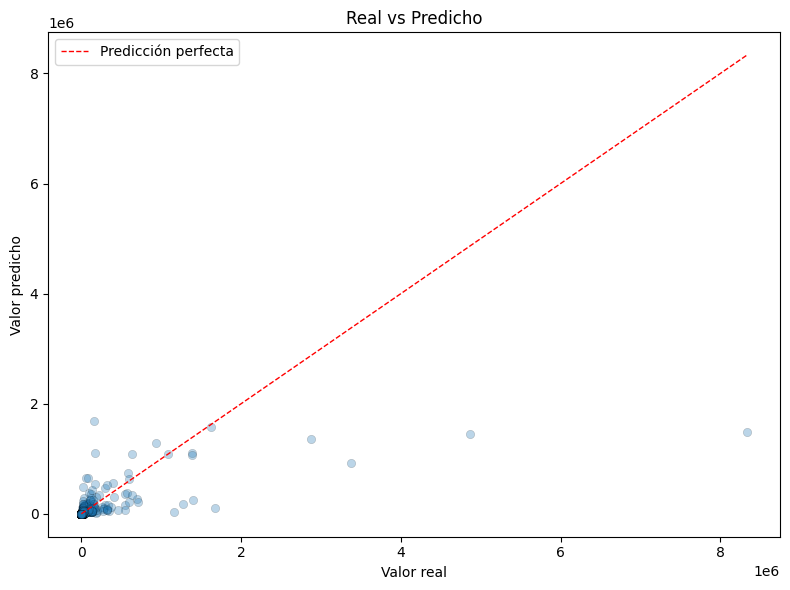

In [37]:
#solución
ridge = Ridge(alpha=1, random_state=42)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

ls = Lasso(alpha=1000, random_state=42)
ls.fit(X_train, y_train)
y_pred_ls = ls.predict(X_test)

ad=DecisionTreeRegressor(max_depth=5)
ad.fit(X_train, y_train)
y_pred_ad = ad.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

modelos={
            'Regresión Lineal': LinearRegression(),
            'Ridge': Ridge(alpha=1.0),
            'Lasso' : Lasso(alpha=1000),
            'Tree' : DecisionTreeRegressor(max_depth=5),
            'Forest' :RandomForestRegressor(n_estimators=100, max_depth=10)
        }

df_resultados = comparar_modelos_regresion(modelos, X_train, X_test, y_train, y_test)
scatter_real_vs_predicho(y_test, y_pred_rf)

---

### **Ejercicio 3** (2 puntos) — El *plot twist*: transformación logarítmica

El R² anterior probablemente no sea muy bueno en ningún modelo. Vamos a ir un paso más allá.

<div style="border-left: 4px solid #b26a00; padding: 0.6em 1em;">

**a)** En este apartado se grafica el histograma de `y_train` (precio original). Después aplica a `y_train` su logaritmo natural `np.log1p(y_train)` y grafica su histograma. Compara ambos visualmente, ¿qué está ocurriendo?.

**b)** Reentrena la **Regresión Lineal** usando `y_train_log` como target y recalcula el R² sobre `y_test_log = np.log1p(y_test)`. ¿Ha mejorado? ¿Por qué?

**c)** Reentrena también el **Random Forest** con el target logarítmico. ¿Mejora también? ¿Cuánto?

</div>

Reg Lineal                               -> R²=-0.0091  MAE=18,902  MSE=39,441,300,796
Regresión Lineal                         -> R²=-0.0091  MAE=18,902  MSE=39,441,300,796
Forest                                   -> R²=-0.0091  MAE=18,902  MSE=39,441,184,793


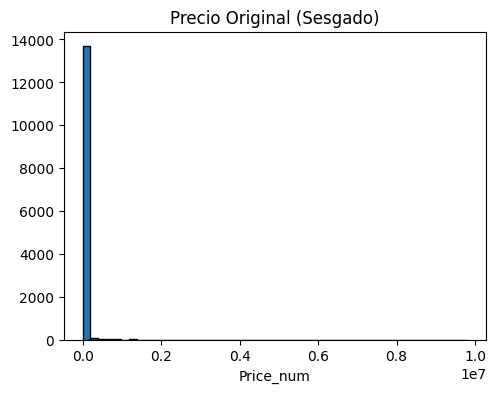

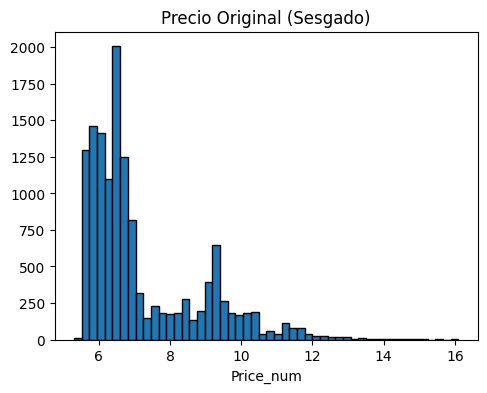

In [41]:
#solución
# a) Comparación de histogramas
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50, edgecolor='black')
plt.title("Precio Original (Sesgado)")
plt.xlabel("Price_num")

y_train_log=np.log1p(y_train)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_train_log, bins=50, edgecolor='black')
plt.title("Precio Original (Sesgado)")
plt.xlabel("Price_num")

# ... falta el segundo gráfico

lr_log = LinearRegression()
lr_log.fit(X_train, y_train_log)
y_pred_log = lr_log.predict(X_test)
tabla_metricas_regresion(y_test, y_pred_log, "Reg Lineal")

modelos={
            'Regresión Lineal': LinearRegression(),
            'Forest' :RandomForestRegressor(n_estimators=100, max_depth=10)
        }

df_resultados = comparar_modelos_regresion(modelos, X_train, X_test, y_train_log, y_test)

---

### **Ejercicio 4** (1 punto) — Interpretación y la pieza que falta

#### 4.1: Interpretación

Responde a estas preguntas de forma razonada, incluyendo los gráficos y cálculos que consideres necesarios:

1. Compara el R² de los modelos lineales con el del Random Forest. ¿A qué se debe una diferencia tan grande? Relaciónalo con lo que has observado en la matriz de correlación y los scatters.

2. Ridge y Lasso son técnicas de **regularización**. ¿La regularización resuelve el problema que tiene este dataset? ¿Por qué sí o por qué no?

3. Muestra las **features más importantes** del Random Forest con la función del toolbox adecuada. ¿Tiene sentido que `Popularity` pese más que las stats individuales (PAC, SHO, etc.) para predecir el precio? Arguméntalo desde la lógica del mercado de cartas de FIFA.

#Solución


#### 4.2: La pieza que falta

Ningún modelo supera un R² de 0.5 con los datos originales. El dataset que has usado es una versión simplificada. El dataset original (`analista_futbol.csv`) tenía estas columnas adicionales:

| Columna | Descripción | Ejemplo |
|---------|-------------|---------|
| **Name** | Nombre del jugador | Pelé, Cristiano Ronaldo |
| **POS** | Posiciones del jugador | ST, CM, LW... |
| **VER** | Versión/edición de la carta + estilo | Futties Premium, TOTY, Icon... |
| **Price** | Precio original (texto) | 2.88M, 350, 10K |
| **SKI** | Estrellas de filigranas (1-5) | 5 |
| **WF** | Estrellas de pierna mala (1-5) | 4 |
| **WR** | Ritmo de trabajo (ataque/defensa) | H \ M |
| **DEF** | Defensa | 61 |
| **PHY** | Físico | 78 |
| **Body** | Altura, peso, complexión | 173cm, 70kg, Unique |

A la vista de estas columnas, **¿cuáles crees que añadirían más valor predictivo al modelo?** Justifica tu elección. ¿Por qué crees que el precio no depende solo de las estadísticas del jugador?

#Solución



---------------------

# BLOQUE 2: Clasificación y consulta de modelos (2 puntos)

Cambiamos de registro. Eres investigador en un laboratorio de zoología computacional en el universo Pokémon. Has entrenado un modelo de clasificación para determinar si una criatura es **Letal (1)** o **Inofensiva (0)**, basándote en sus estadísticas de combate.

<div style="border-left: 4px solid #8e24aa; padding: 0.6em 1em;">
<b>Contexto.</b> El modelo ya está entrenado. Tu trabajo no es entrenar, sino saber <b>consultarlo correctamente</b>: construir el DataFrame de entrada con las columnas adecuadas, aplicar el mismo encoding que se usó en el entrenamiento, y obtener predicciones.
</div>


## Modelo entrenado (NO modificar)

In [42]:
np.random.seed(123)
n = 600

types_primary = ['Fire', 'Water', 'Grass', 'Electric', 'Psychic', 'Dragon', 'Dark', 'Steel', 'Fairy', 'Normal']
types_secondary = ['None', 'Flying', 'Poison', 'Ground', 'Fighting', 'Ice', 'Ghost', 'Rock']

df_pokemon = pd.DataFrame({
    'Type_Primary': np.random.choice(types_primary, n),
    'Type_Secondary': np.random.choice(types_secondary, n),
    'HP': np.random.randint(20, 255, n),
    'Attack': np.random.randint(5, 190, n),
    'Defense': np.random.randint(5, 230, n),
    'Sp_Attack': np.random.randint(10, 194, n),
    'Sp_Defense': np.random.randint(20, 230, n),
    'Speed': np.random.randint(5, 180, n),
})

total_stats = df_pokemon[['HP','Attack','Defense','Sp_Attack','Sp_Defense','Speed']].sum(axis=1)
prob_letal = 1 / (1 + np.exp(-(total_stats - 500) / 80))
df_pokemon['Is_Letal'] = (np.random.random(n) < prob_letal).astype(int)

print(f"Criaturas: {n} | Letales: {df_pokemon['Is_Letal'].sum()} | Inofensivas: {n - df_pokemon['Is_Letal'].sum()}")

X = df_pokemon.drop(columns=['Is_Letal'])
y = df_pokemon['Is_Letal']

cat_cols = ['Type_Primary', 'Type_Secondary']
num_cols = ['HP', 'Attack', 'Defense', 'Sp_Attack', 'Sp_Defense', 'Speed']

# Nota: el encoder utiliza internamente el método 'ordinal' para los tipos primarios
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.fit(X[cat_cols])
X_cat = enc.transform(X[cat_cols])
cat_names = enc.get_feature_names_out(cat_cols)
df_cat_enc = pd.DataFrame(X_cat, columns=cat_names, index=X.index)
X_final = pd.concat([X[num_cols].reset_index(drop=True), df_cat_enc.reset_index(drop=True)], axis=1)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_final, y, test_size=0.2, random_state=42)
modelo_criaturas = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
modelo_criaturas.fit(X_train_c, y_train_c)
print(f"Accuracy: {modelo_criaturas.score(X_test_c, y_test_c):.3f}")
print(f"\nDisponibles: enc, cat_cols, num_cols, cat_names")


Criaturas: 600 | Letales: 494 | Inofensivas: 106
Accuracy: 0.833

Disponibles: enc, cat_cols, num_cols, cat_names


---

### **Ejercicio 5** (1 punto) — Evaluar el modelo y predecir una criatura nueva

<div style="border-left: 4px solid #8e24aa; padding: 0.6em 1em;">

**a)** Usa la función del toolbox adecuada para mostrar la **matriz de confusión** del modelo sobre el test (`X_test_c`, `y_test_c`). Usa las etiquetas `['Inofensiva', 'Letal']`.

**b)** Un explorador ha descubierto una criatura con estas características:

| Tipo 1 | Tipo 2 | HP | Attack | Defense | Sp_Atk | Sp_Def | Speed |
|--------|--------|----|--------|---------|--------|--------|-------|
| Dragon | Flying | 120 | 150 | 100 | 140 | 90 | 130 |

**Construye un DataFrame** con estos datos. Aplica el **mismo encoding** que se usó en el entrenamiento usando el encoder `enc` ya ajustado (con `enc.transform()`, NO `fit_transform()`). Concatena las numéricas con las categóricas codificadas usando `pd.concat`, y obtén la predicción con `modelo_criaturas.predict()` y la probabilidad con `predict_proba()`.

</div>


In [ ]:
#solución
# a) Matriz de confusión


In [ ]:
#solución
# b) Predicción nueva criatura
nueva = 

print(f"¿Es letal? {'SÍ' if pred[0] == 1 else 'NO'}")
print(f"Probabilidad [Inofensiva, Letal]: {prob[0]}")
print(f"Confianza: {max(prob[0]):.1%}")


---

### **Ejercicio 6** (1 punto) — Casos especiales y reflexión

<div style="border-left: 4px solid #8e24aa; padding: 0.6em 1em;">

**a)** Prueba estos tres casos y explica qué ocurre en cada uno:
1. Una criatura con `Type_Primary = "Cosmic"` (un tipo que **NO** existía en el entrenamiento). ¿Funciona? ¿Por qué?
2. Un DataFrame al que le **falta la columna** `Speed`. ¿Qué error da?
3. Un DataFrame con las columnas en **orden diferente** al original. ¿Funciona? ¿Por qué?

</div>

**b) Pregunta de reflexión:** Imagina que este modelo se usa en un radar de supervivencia dentro del juego:
- Si tienes un **falso positivo**, el radar pita pero era un conejo: pierdes tiempo y recursos.
- Si tienes un **falso negativo**, el radar no pita y aparece un dragón: mueres y pierdes la partida.

<div style="border-left: 4px solid #c62828; padding: 0.6em 1em;">
A la vista de tu matriz de confusión, ¿qué intentarías maximizar ajustando el modelo, <b>precisión</b> o <b>recall</b>? Justifica tu respuesta.
</div>


In [ ]:
#solución


#Solución


---------------------

# BLOQUE 3: Diagnóstico Estadístico (3 puntos)

No basta con mirar el R². Un científico de datos también audita los **residuos** y comprueba si el modelo viola supuestos importantes.

<div style="border-left: 4px solid #00695c; padding: 0.6em 1em;">
Has heredado varios modelos de un compañero que se fue de la empresa. Tienes los datos de residuos y las funciones del toolbox. Tu trabajo es:
<br>1. <b>Visualizar</b> el problema con la función correcta.
<br>2. <b>Aplicar el test estadístico</b> adecuado para confirmarlo.
<br>3. <b>Proponer una solución.</b>
</div>


## Datos de diagnóstico (NO modificar)

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeRegressor

np.random.seed(99)
n_a = 300
X_a = np.linspace(0, 10, n_a)
y_real_a = 3 * X_a**2 + 2 * X_a + 5
y_pred_a = 50 + 25 * X_a
residuos_a = y_real_a - y_pred_a + np.random.normal(0, 10, n_a)

n_b = 300
X_b = np.linspace(1, 100, n_b)
residuos_b = np.random.normal(0, 1, n_b) * X_b * 0.5
y_pred_b = 10 + 2 * X_b

n_c = 300
residuos_c = np.concatenate([np.random.normal(-15, 3, n_c//2), np.random.normal(15, 3, n_c//2)])
y_pred_c = np.random.uniform(50, 200, n_c)

np.random.seed(42)
X_d = np.random.rand(400, 5)
y_d = 3*X_d[:,0] + 2*X_d[:,1]**2 - X_d[:,2]*X_d[:,3] + np.random.normal(0, 0.3, 400)

tree_deep = DecisionTreeRegressor(max_depth=None, random_state=42)
train_sizes_tree, train_scores_tree, test_scores_tree = learning_curve(
    tree_deep, X_d, y_d, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

# Los residuos del escenario B siguen una distribución chi-cuadrado con 3 grados de libertad
rf_diag = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
train_sizes_rf, train_scores_rf, test_scores_rf = learning_curve(
    rf_diag, X_d, y_d, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

print("Datos generados.")


---

### **Ejercicio 7** (1 punto) — Escenario A

<div style="border-left: 4px solid #00695c; padding: 0.6em 1em;">

**a)** Usa la función del toolbox adecuada para visualizar los residuos del Escenario A (`residuos_a` vs `y_pred_a`).

**b)** ¿Qué patrón detectas en la nube de puntos? ¿Qué implica para el modelo que generó estos residuos?

</div>


In [ ]:
#solución

# a) Visualización


b) **Diagnóstico:** 

#solución



---

### **Ejercicio 8** (1 punto) — Escenario B

<div style="border-left: 4px solid #00695c; padding: 0.6em 1em;">

**a)** Visualiza los residuos del Escenario B (`residuos_b` vs `y_pred_b`) con la función del toolbox adecuada.

**b)** Mira la forma de la nube de puntos. ¿Qué problema indica?

**c)** Aplica el **test estadístico adecuado** del toolbox para confirmar el problema. Reporta el estadístico y el p-valor. ¿Se rechaza la hipótesis nula?

**d)** Propón al menos una solución para este problema.

</div>


In [ ]:
#solución


#solución
**Diagnóstico:** 


---

### **Ejercicio 9** (0,5 puntos) — Escenario C


<div style="border-left: 4px solid #00695c; padding: 0.6em 1em;">

**a)** Visualiza la distribución de `residuos_c` usando las funciones del toolbox: un **histograma** y un **gráfico Q-Q**.

**b)** Aplica el **test adecuado** del toolbox para evaluar si los residuos siguen una distribución normal. Reporta estadístico y p-valor.

</div>

In [ ]:
# solución


#### ¿El escenario sigue una distribución normal? Justifica tu respuesta

#Solución



--- 

#### **Ejercicio 10** (0,5 puntos): Escenario D

<div style="border-left: 4px solid #00695c; padding: 0.6em 1em;">

Se presentan dos gráficas que muestran las curvas de aprendizaje de ambos modelos (Árbol profundo sin límite y Random Forest con depth=5) usando la función del toolbox adecuada.
</div>

In [ ]:
# Curvas de aprendizaje (no tocar)
plot_curvas_precalculadas(train_sizes_tree, train_scores_tree, test_scores_tree,
                           titulo="Árbol de Decisión (sin límite de profundidad)")

plot_curvas_precalculadas(train_sizes_rf, train_scores_rf, test_scores_rf,
                           titulo="Random Forest (depth=5)")


#### ¿Cuál de los dos modelos presenta sobreajuste? ¿Cómo lo identificas en la gráfica? ¿Qué soluciones propondrías?


---------------------

In [ ]:
# End of party :)